### Transformada Rápida de Fourier (FFT)

### 1. Introdução

Para obter todos os coeficientes de $X(k)$ pelo cálculo direto da DFT, temos que a $\text{complexidade: } \mathcal{O}(N^2)$

Essa complexidade limita o uso da DFT direta para sinais longos. Em 1965, Cooley e Tukey propuseram um algoritmo que reduz a complexidade para $\mathcal{O}(N\log_2 N)$, explorando duas propriedades do fator de giro $W_N = e^{-j\frac{2\pi}{N}}$:

$$W_N^{k(N-n)} = W_N^{-kn} = \left(W_N^{kn}\right)^{*} \quad \text{(simetria complexa conjugada)}$$

$$W_N^{kn} = W_N^{k(N+n)} = W_N^{(k+N)n} \quad \text{(periodicidade em } k \text{ e } n\text{)}$$

Essa classe de algoritmos é conhecida como Transformada Rápida de Fourier (FFT).

### 2. Decomposição em Subsequências Pares e Ímpares (Decimação no Tempo)

Para $N$ potência de 2, a sequência $x(n)$ de $N$ pontos é dividida em duas subsequências de $N/2$ pontos: uma relativa aos índices pares e outra aos índices ímpares.

$$X(k) = \sum_{n=0}^{N-1} x(n)\,W_N^{kn} = \sum_{n \text{ par}} x(n)\,W_N^{kn} + \sum_{n \text{ ímpar}} x(n)\,W_N^{kn}$$

Fazendo $n=2r$ (pares) e $n=2r+1$ (ímpares), e usando $W_N^2 = W_{N/2}$:

$$X(k) = \sum_{r=0}^{N/2-1} x(2r)\,W_{N/2}^{rk} + W_N^{k}\sum_{r=0}^{N/2-1} x(2r+1)\,W_{N/2}^{rk}$$

Definindo $x_e(n) = x(2n)$ e $x_o(n) = x(2n+1)$, com $X_e(k)$ e $X_o(k)$ as respectivas DFTs de $N/2$ pontos:

$$\boxed{X(k) = X_e(k) + W_N^{k}\,X_o(k)}$$

Como $X_e(k)$ e $X_o(k)$ são periódicas com período $N/2$:

$$X_e(k) = X_e(k+N/2) \qquad X_o(k) = X_o(k+N/2)$$

Se $N/2$ ainda for par, $x_e(n)$ e $x_o(n)$ podem ser decompostas novamente em pares e ímpares.

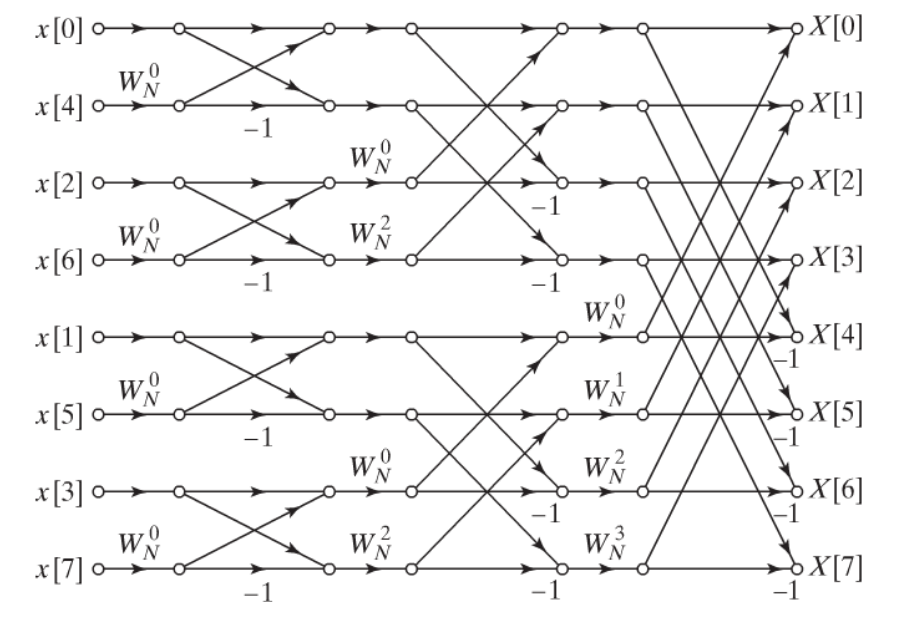
<p style="text-align:center; font-size:0.9em; color:white;">
Fonte: VELOSO, Luciana Ribeiro. <i>Processamento Digital de Sinais</i>
</p>

### 3. Uso da Butterfly

A solução básica de cálculo da FFT é a borboleta: ela combina duas amostras usando o fator de giro $W$, produzindo duas saídas:

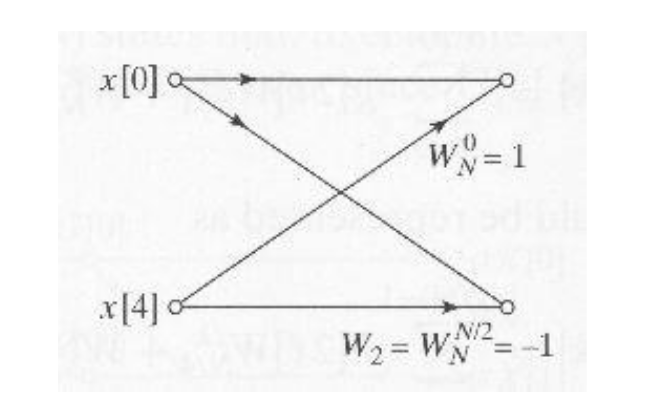
<p style="text-align:center; font-size:0.9em; color:white;">
Fonte: VELOSO, Luciana Ribeiro. <i>Processamento Digital de Sinais</i>
</p>

$$\boxed{X_{topo} = A + W\cdot B \qquad X_{base} = A - W\cdot B}$$

### 4. Reordenação Bit-Reversal

Separar pares e ímpares na prática, separando o vetor passo a passo, seria lento. Uma solução rápida computacionalmente é o uso do bit-reversal: ele calcula de antemão a posição final de cada amostra, permitindo reorganizar o vetor de uma só vez, no início.

Para cada índice $i$ (com $\log_2(N)$ bits):

1. Converte-se $i$ para binário (ex.: índice 1 vira 001);
2. Inverte-se a ordem dos bits (001 $\to$ 100);
3. Converte-se de volta para decimal, obtendo o novo índice (4).

A amostra $x(i)$ é então movida para essa nova posição.

| Índice original | Binário | Bits invertidos | Novo índice |
|---|---|---|---|
| 0 | 000 | 000 | 0 |
| 1 | 001 | 100 | 4 |
| 2 | 010 | 010 | 2 |
| 3 | 011 | 110 | 6 |
| 4 | 100 | 001 | 1 |
| 5 | 101 | 101 | 5 |
| 6 | 110 | 011 | 3 |
| 7 | 111 | 111 | 7 |

### 5. Implementação 

Fórmula:

$$X(k) = X_e(k) + W_N^{k}\,X_o(k)$$
$$W_N^{k} = e^{-j\frac{2\pi}{N}k}$$

In [1]:
# Importando bibliotecas.
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
def bit_reversal(x):
    """
    Função para realizar a inversão dos indices das amostras.
    
    Solução:
    invertido = texto[::-1] --> 001 --> 100
    """
    
    N = len(x)
    x_invertido = np.zeros(N, dtype = complex)
    num_bits = int(np.log2(N))
    
    # Iniciando o laço para realizar a inversão.
    for i in range (N):
        
        # Transformando o indice em texto binário.
        indice = f"{i:0{num_bits}b}"
        
        # Inverte a ordem dos textos do indice.
        inverte = indice[::-1]
        
        # Converter para inteiro binário.
        indice = int(inverte,2)
        
        # Insere o valor da amostra original ao novo indice.
        x_invertido[indice] = x[i]
        
    return x_invertido, num_bits

In [3]:
def fft_2(x_in):
    """
    Função para realizar a DFT iterativa (fft).
    
    Solução:
    Usando o metodo borboleta, conseguimos reduzir a complexidade da DFT.
    """
    
    N = len(x_in)
    x, num_bits = bit_reversal(x_in)
    
    for i in range (num_bits):
        
        # 1° laço: Iniciando todo o processo definindo o tamanho do bloco inicial.
        tamanho_bloco = 2 ** (1 + i)
        metade_bloco  = tamanho_bloco // 2
        
        for inicio_par in range (0, N, tamanho_bloco):
            
            # 2° laço: Determina o inicio do bloco, onde se encontra os valores pares.
            
            for k in range (metade_bloco):
                
                # 3° laço: Motor do metódo borboleta.
                indice_par = inicio_par + k
                indice_impar = inicio_par + k + metade_bloco
                a = x[indice_par]
                b = x[indice_impar]
                w = np.exp(-1j*(2*np.pi / tamanho_bloco)*k)
                c = w*b
                           
                x_positivo = a + c
                x_negativo = a - c
                
                x[indice_par] = x_positivo
                x[indice_impar] = x_negativo
                            
    return x

### 6. Custo Computacional da FFT

Repetindo a decomposição até restarem apenas DFTs de 2 pontos (cada um dos $\log_2 N$ estágios contribuindo com $N/2$ multiplicações complexas via borboletas), obtém-se:

$$\boxed{\text{Multiplicações complexas: } \frac{N}{2}\log_2 N \qquad \text{Complexidade: } \mathcal{O}(N\log_2 N)}$$

In [4]:
def medir_tempo_fft_2(x):
    """
    Recebe um sinal x (comprimento potência de 2) e mede o tempo da FFT.
    """
    x = np.array(x, dtype=complex)

    # Nossa FFT
    t0 = time.time()
    X_fft = fft_2(x)
    t_fft = (time.time() - t0) * 1000

    print(f"Tamanho do sinal:  N = {len(x)}")
    print(f"FFT:               {t_fft:.4f} ms")

    return X_fft

In [6]:
print("=== Implementação da Transformada Rápida de Fourier (FFT) ===")
print("Digite os valores das amostras separados por espaço (ex: 0 1 2 3):")

L = int(input("Quantidade de amostras do sinal (L, potência de 2): "))

# Verifica se L é potência de 2.
if (L & (L - 1)) != 0:
    raise ValueError(f"L={L} não representa uma potência de 2. Informe um novo valor!)")

np.random.seed(42)
x = np.random.randn(L)

X = medir_tempo_fft_2(x)

print(f"\n=== Saída da FFT ({L} pontos) ===")

if len(X) > 10:
    t = 10
else:
    t = len(X)

for i in range(t):
    print(f"  X[{i}] = {X[i]:.2f}")

=== Implementação da Transformada Rápida de Fourier (FFT) ===
Digite os valores das amostras separados por espaço (ex: 0 1 2 3):
Tamanho do sinal:  N = 1024
FFT:               6.7294 ms

=== Saída da FFT (1024 pontos) ===
  X[0] = 30.08+0.00j
  X[1] = 29.15+8.67j
  X[2] = -30.28+34.26j
  X[3] = -14.00+22.97j
  X[4] = -34.86-9.42j
  X[5] = 25.65+13.12j
  X[6] = -1.41-2.54j
  X[7] = 27.36-17.36j
  X[8] = 8.44+20.10j
  X[9] = 9.46+29.13j


In [7]:
import json

tamanhos = [16, 32, 64, 128, 256, 512, 1024, 2048]
REPETICOES = 5

tempos_ms = []

for N in tamanhos:
    np.random.seed(42)
    x = np.random.randn(N)
    medicoes = []
    for _ in range(REPETICOES):
        t0 = time.time()
        fft_2(x)
        medicoes.append((time.time() - t0) * 1000)
    media = round(float(np.mean(medicoes)), 4)
    tempos_ms.append(media)
    print(f"N = {N:5d} → {media:.4f} ms")

metricas = {
    "nome"        : "FFT Potência-2",
    "tamanhos"    : tamanhos,
    "tempos_ms"   : tempos_ms
}

with open("fft_radix2_metrics.json", "w") as f:
    json.dump(metricas, f, indent=2)

print("\nSalvo em fft_radix2_metrics.json")

N =    16 → 0.0712 ms
N =    32 → 0.1382 ms
N =    64 → 0.2957 ms
N =   128 → 0.6556 ms
N =   256 → 1.1911 ms
N =   512 → 2.5699 ms
N =  1024 → 2.4196 ms
N =  2048 → 5.4091 ms

Salvo em fft_radix2_metrics.json
